# 10_强化学习-SARSA

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


今天给大家分享强化学习中，非常重要的一个算法模型，SARSA。

SARSA用于**求解最优策略**，让智能体在环境中学习如何做出最佳决策。

它是一种基于**时序差分（Temporal Difference, TD）的 基于策略（on-policy） 控制算法，能够在未知环境中自我学习**。

首先，SARSA 的更新公式：


$$
Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha \left[ r_t + \gamma Q(s_{t+1}, a_{t+1}) - Q(s_t, a_t) \right]
$$


其中：

- $Q(s, a)$：状态 $s$ 下执行动作 $a$ 的 **Q 值**（即该动作的长期收益估计）
- $\alpha$：学习率（learning rate），控制学习速度
- $r_t$：当前奖励（reward）
- $\gamma$：折扣因子（discount factor），控制对未来奖励的重视程度
- $s_t, a_t$：当前状态和动作
- $s_{t+1}, a_{t+1}$：下一步的状态和动作

### 简单解释

SARSA 的核心逻辑是：

1. **观察环境，获取当前状态** $s_t$
2. **用 ε-贪心策略选择一个动作** $a_t$（探索 vs. 利用）
3. **执行动作，获取奖励** $r_t$**，转移到新状态** $s_{t+1}$
4. **根据当前策略选择下一步的动作** $a_{t+1}$
5. **用公式更新 Q 值，告诉自己“这个决策好不好”**
6. **不断重复，直到学会最优策略**

**简单举例**：

- 你在一个迷宫里，想找到出口，同时避免陷阱。
- 每次你选择一个方向（动作），然后观察自己是更接近出口（+奖励）还是撞到墙（-惩罚）。
- 你会根据过去的经验决定下一步该怎么走。
- 经过大量尝试，你最终学会了一条从起点到终点的最佳路径。

### SARSA vs Q-learning（区别）

| **算法** | **策略类型** | **学习方式** | **探索性** |
|-|-|-|-|
| **SARSA** | 基于策略（on-policy） | 使用自己当前的策略学习 | 比较稳定，适合动态环境 |
| **Q-learning** | 非基于策略（off-policy） | 使用最优策略进行学习 | 更容易找到全局最优，但不稳定 |

简单来说：

- **SARSA** 是一个 **稳妥派**，它学到的策略是基于**自己正在执行的策略**，不会突然跳到全新的方法。
- **Q-learning** 是一个 **激进派**，它直接用**最优 Q 值**来学习，可能会跳跃式地优化，但不一定稳定。

**打游戏举例**：

- **SARSA**：你玩游戏时，**慢慢调整自己的策略**，学会了**稳妥的玩法**，不会突然改变风格。
- **Q-learning**：你直接**看攻略**，学习最优打法，但有时候你的操作可能跟不上，导致失误。

### SARSA 算法流程

1. **初始化 Q 表**（所有状态-动作的 Q 值设为 0）
2. **循环进行训练**（直到收敛）

   - 观察当前状态 $s_t$
   - 用 ε-贪心策略选动作 $a_t$
   - 执行动作，获得奖励 $r_t$，到达新状态 $s_{t+1}$
   - 根据当前策略选择新动作 $a_{t+1}$
   - 用 SARSA 公式更新 Q 值
   - 继续执行，直到任务完成

### 机器人学会走迷宫

| 状态 $s$ | 机器人可执行的动作 $a$ | 奖励 $r$ | 新状态 $s'$ |
|-|-|-|-|
| (0,0) 起点 | 右移 | -0.1 | (0,1) |
| (0,1) | 右移 | -0.1 | (0,2) |
| (0,2) | 下移 | -0.1 | (1,2) |
| (1,2) | 右移 | -0.1 | (1,3) |
| (1,3) | 右移 | **+1**（终点） | (1,4) |

**SARSA 学习后：**

- 机器人一开始**到处乱撞**，因为它在探索。
- 逐渐地，它记住了哪些方向有奖励，哪些方向是死路。
- 训练结束后，它会优先选择**最短路径**到达终点！

总结几点：

**SARSA 就像一个学习开车的新手**：

- 一开始你会到处试（探索）。
- 你撞过几次墙（负奖励），慢慢学会了避开障碍。
- 你发现某些路很顺畅（正奖励），所以开始优先走这些路。
- 你不会**突然完全改变开车方式**，而是**不断优化你当前的驾驶技巧**。
- 经过大量练习，你最终学会了最稳妥的驾驶方式。

## 理论基础

SARSA 使用 **Q 值更新公式** 来不断优化智能体的决策过程。

其核心数学表达式：


$$
Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha \left[ r_t + \gamma Q(s_{t+1}, a_{t+1}) - Q(s_t, a_t) \right]
$$


其中：

- $Q(s_t, a_t)$：当前状态 $s_t$下执行动作 $a_t$的 **Q 值**（即该动作的长期收益估计）。
- $\alpha$：学习率（learning rate），控制新信息的学习速度，取值范围为 $0 < \alpha \leq 1$。
- $r_t$：当前时间步获得的奖励（reward）。
- $\gamma$：折扣因子（discount factor），决定智能体对未来奖励的重视程度，取值范围 $0 \leq \gamma \leq 1$。
- $s_{t+1}$：执行 $a_t$后的新状态。
- $a_{t+1}$：在 $s_{t+1}$下按照当前策略选择的下一步动作。

### SARSA 的 Q 值更新逻辑

- 计算 **当前状态-动作对的 Q 值**（旧值）
- 计算 **下一状态-动作对的 Q 值**（下一步的预期收益）
- 结合奖励 $r_t$进行更新，使 Q 值朝着未来收益的方向调整

$\text{目标值} = r_t + \gamma Q(s_{t+1}, a_{t+1})$  
$\text{误差} = \text{目标值} - Q(s_t, a_t)$  
$Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha \times \text{误差}$

### SARSA 算法流程

SARSA 通过以下步骤让智能体在环境中学习最优策略：

#### 1）初始化

- 初始化 **Q 表（Q-table）**，记录所有状态-动作对的 Q 值：  
$Q(s, a) = 0, \quad \forall s \in S, \quad a \in A$
- 设定 **学习率** $\alpha$**、折扣因子** $\gamma$**、探索率** $\epsilon$。
- 设定最大训练回合数 $\text{max\_episodes}$。

#### 2）开始训练

#### 循环执行，直到达到最大回合数

1. **环境初始化**

   - 让智能体进入初始状态 $s_0$。
   - 选择**初始动作** $a_0$（根据 ε-贪心策略）。
2. **重复执行，直到终止状态**

   - **执行动作** $a_t$**，获得奖励** $r_t$**，到达新状态** $s_{t+1}$：  
   $s_{t+1}, r_t \leftarrow \text{step}(s_t, a_t)$
   - **根据当前策略选择** $s_{t+1}$**下的动作** $a_{t+1}$  
   $a_{t+1} \leftarrow \pi(s_{t+1})$
   - **更新 Q 值**  
   $Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha \left[ r_t + \gamma Q(s_{t+1}, a_{t+1}) - Q(s_t, a_t) \right]$
   - **更新当前状态和动作**  
   $s_t \leftarrow s_{t+1}, \quad a_t \leftarrow a_{t+1}$
3. **如果智能体到达终止状态，结束本回合，进入下一回合。**

### SARSA 中的探索与利用

为了确保智能体既能探索新策略，又能利用已有经验，SARSA 采用**ε-贪心策略**选择动作：


$$
a =\begin{cases}\text{随机动作}, & \text{概率} \quad \epsilon \\\arg\max\limits_{a} Q(s, a), & \text{概率} \quad 1 - \epsilon\end{cases}
$$


- **探索（Exploration）**：以 ε 概率随机选择动作，避免局部最优解。
- **利用（Exploitation）**：以 $1-\epsilon$概率选择当前 Q 值最大的动作。

通常，ε 会**逐渐减少**，使得智能体前期多探索，后期多利用。

## 完整案例

**任务背景**：智能体在一个 5x5 的网格世界中移动，目标是到达终点，过程中会遇到障碍物和奖励点。

我们将训练 SARSA 代理，让它学会最优策略，并绘制以下 4 个分析图：

- 训练过程中 **累计奖励变化**
- 训练过程中 **平均 Q 值变化**
- 训练后的 **最优策略可视化**
- **Q 值热力图**（展示不同状态的 Q 值）

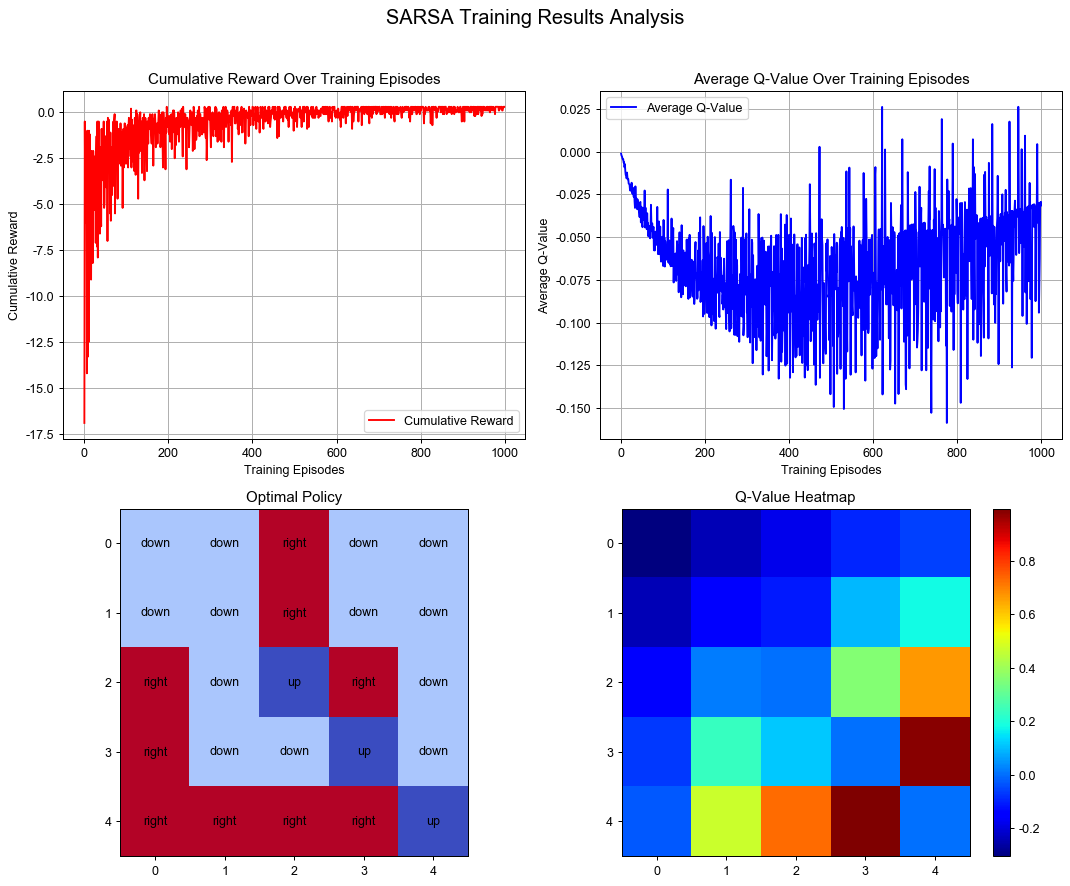

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random

# 设置 GridWorld 参数
GRID_SIZE = 5
ACTIONS = ['up', 'down', 'left', 'right']
ACTION_MAP = {0: (-1, 0), 1: (1, 0), 2: (0, -1), 3: (0, 1)}

# 环境类
class GridWorld:
    def __init__(self):
        self.grid_size = GRID_SIZE
        self.start_state = (0, 0)
        self.end_state = (4, 4)
        self.obstacles = [(2, 2), (3, 3)]
        self.state = self.start_state

    def reset(self):
        self.state = self.start_state
        return self.state

    def step(self, action):
        next_state = (self.state[0] + ACTION_MAP[action][0], self.state[1] + ACTION_MAP[action][1])

        if next_state[0] < 0 or next_state[0] >= self.grid_size or \
           next_state[1] < 0 or next_state[1] >= self.grid_size or \
           next_state in self.obstacles:
            next_state = self.state  # 撞墙或障碍物

        reward = 1 if next_state == self.end_state else -0.1
        done = next_state == self.end_state

        self.state = next_state
        return next_state, reward, done

# SARSA 代理类
class SARSA_Agent:
    def __init__(self, lr=0.01, gamma=0.9, epsilon=0.1):
        self.lr = lr
        self.gamma = gamma
        self.epsilon = epsilon
        self.q_table = np.zeros((GRID_SIZE, GRID_SIZE, len(ACTIONS)))

    def choose_action(self, state):
        if random.uniform(0, 1) < self.epsilon:
            return random.randint(0, len(ACTIONS) - 1)  # 采取随机探索
        return np.argmax(self.q_table[state[0], state[1]]).item()  # 采取贪婪策略

    def update(self, state, action, reward, next_state, next_action):
        q_predict = self.q_table[state[0], state[1], action]
        q_target = reward + self.gamma * self.q_table[next_state[0], next_state[1], next_action]
        self.q_table[state[0], state[1], action] += self.lr * (q_target - q_predict)

# 训练 SARSA 代理
def train_sarsa(episodes=1000):
    env = GridWorld()
    agent = SARSA_Agent()
    rewards_per_episode = []
    avg_q_values = []

    for episode in range(episodes):
        state = env.reset()
        action = agent.choose_action(state)
        total_reward = 0
        q_values = []

        while True:
            next_state, reward, done = env.step(action)
            next_action = agent.choose_action(next_state)
            agent.update(state, action, reward, next_state, next_action)
            
            total_reward += reward
            q_values.append(agent.q_table[state[0], state[1]].mean().item())

            if done:
                break
            state, action = next_state, next_action
        
        rewards_per_episode.append(total_reward)
        avg_q_values.append(np.mean(q_values))

    return agent, rewards_per_episode, avg_q_values

# 训练模型
agent, rewards, q_values = train_sarsa()

# 生成策略图
def generate_policy_map(agent):
    policy_map = np.zeros((GRID_SIZE, GRID_SIZE))
    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):
            if (i, j) in [(4, 4), (2, 2), (3, 3)]:
                continue
            policy_map[i, j] = np.argmax(agent.q_table[i, j]).item()
    return policy_map

# 生成 Q 值热力图
def generate_q_value_heatmap(agent):
    q_values = np.zeros((GRID_SIZE, GRID_SIZE))
    for i in range(GRID_SIZE):
        for j in range(GRID_SIZE):
            q_values[i, j] = agent.q_table[i, j].max().item()
    return q_values

# 可视化结果
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("SARSA Training Results Analysis", fontsize=16, fontweight='bold')

# 1. 累计奖励变化
axs[0, 0].plot(rewards, color='red', label='Cumulative Reward')
axs[0, 0].set_title("Cumulative Reward Over Training Episodes", fontsize=12)
axs[0, 0].set_xlabel("Training Episodes")
axs[0, 0].set_ylabel("Cumulative Reward")
axs[0, 0].legend()
axs[0, 0].grid(True)

# 2. 平均 Q 值变化
axs[0, 1].plot(q_values, color='blue', label='Average Q-Value')
axs[0, 1].set_title("Average Q-Value Over Training Episodes", fontsize=12)
axs[0, 1].set_xlabel("Training Episodes")
axs[0, 1].set_ylabel("Average Q-Value")
axs[0, 1].legend()
axs[0, 1].grid(True)

# 3. 最优策略可视化
policy_map = generate_policy_map(agent)
axs[1, 0].imshow(policy_map, cmap='coolwarm', interpolation='nearest')
axs[1, 0].set_title("Optimal Policy", fontsize=12)
for i in range(GRID_SIZE):
    for j in range(GRID_SIZE):
        axs[1, 0].text(j, i, ACTIONS[int(policy_map[i, j])], ha='center', va='center', color='black')

# 4. Q 值热力图
q_heatmap = generate_q_value_heatmap(agent)
im = axs[1, 1].imshow(q_heatmap, cmap='jet', interpolation='nearest')
axs[1, 1].set_title("Q-Value Heatmap", fontsize=12)
fig.colorbar(im, ax=axs[1, 1])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### 优化点

- **动态 ε-贪心策略**（逐渐降低 ε 以减少探索，提高利用）
- **自适应学习率**（随训练次数调整）
- **改进奖励机制**（负奖励让训练更稳定）

![原文参考图，当前结果见代码输出](attachments/img_002.png)

1. **累计奖励曲线**：展示了训练过程中奖励的增长情况
2. **平均 Q 值曲线**：观察 Q 值随训练的变化趋势
3. **最优策略可视化**：显示智能体学习到的最优策略
4. **Q 值热力图**：查看不同状态的最优 Q 值

## 应用场景

### SARSA 适用于哪类问题？

- **动态、非确定性环境**（环境可能随时间变化）
- **连续决策问题**（需要不断决策，不是一次性决策）
- **存在探索风险的任务**（避免激进探索带来的高风险）
- **有限状态-动作空间**（但可扩展到函数逼近，如深度学习）
- **需要平衡探索与利用的强化学习任务**

典型应用场景：

- **机器人控制**（路径规划、避障）
- **游戏 AI 训练**（自适应学习策略）
- **自动驾驶**（决策与避障）
- **智能交易系统**（动态市场策略）
- **流量控制**（网络负载均衡）

### SARSA 的优缺点

**优点**

1. **稳定性高**：由于 SARSA 是 **基于策略（on-policy）** 算法，它在训练过程中不会突然跳到最优策略，因此更稳定，适用于动态环境。
2. **避免极端探索**：由于 SARSA 的更新方式依赖于当前策略，它不会直接选择最优 Q 值，因此能避免 Q-learning 过度探索高风险策略的问题。
3. **适用于变化环境**：在实时变化的环境（如自适应系统、股票交易）中，比 Q-learning 更稳健。
4. **探索利用均衡**：ε-贪心策略可平衡探索（尝试新策略）和利用（执行当前最佳策略）。

**缺点**

1. **收敛速度较慢**：SARSA 需要更多时间来探索和学习合适的策略，比 Q-learning 慢。
2. **容易陷入局部最优**：由于它是基于当前策略学习的，可能无法跳出次优策略。
3. **对 ε 依赖性强**：ε 需要合理调节，否则探索不足或过度探索会影响学习效果。
4. **不适用于大规模问题**：传统 SARSA 依赖 Q 表存储 Q 值，状态空间太大时，存储和计算成本高（但可以用深度学习扩展）。

### 运行 SARSA 需要的前提条件

1. **环境可交互**：智能体必须能够与环境交互，并获取状态、动作、奖励等信息。
2. **状态和动作可定义**：问题需要能够定义 **状态集合** $S$和 **动作集合** $A$。
3. **可获取奖励信号**：智能体在执行动作后，环境需要提供一个奖励信号 $r$来指导学习。
4. **满足马尔可夫性质（MDP）**：未来状态仅取决于当前状态和当前动作（不依赖过去的状态）。
5. **探索机制可调控**：如 ε-贪心策略控制探索程度。